# Análise de Crédito em Minas Gerais

Este notebook realiza uma análise completa dos dados de crédito em Minas Gerais utilizando a API do Banco Central (Sistema de Gerenciamento de Séries Temporais - SGS). Apresentamos visualizações do **saldo das operações de crédito** e **taxas de inadimplência** para pessoas físicas, jurídicas e o total.

## 1. Importação de Bibliotecas

Importamos as bibliotecas necessárias para manipulação de dados, requisições HTTP e visualização de gráficos:
- **pandas**: Manipulação e análise de dados
- **requests**: Requisições HTTP para a API do Banco Central
- **matplotlib**: Criação de gráficos avançados com formatação de datas

In [1]:
# Importando as bibliotecas necessárias
import pandas as pd
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

## 2. Função de Consulta à API do Banco Central

A função `consulta_bc()` realiza requisições à API do Banco Central (Sistema de Gerenciamento de Séries - SGS) para obter dados econômicos. O processo inclui:

1. **Requisição HTTP**: Busca dados em formato JSON
2. **Tratamento de Erros**: Valida a resposta da API
3. **Transformação de Dados**: 
   - Converte datas no formato brasileiro (dd/mm/yyyy)
   - Converte valores para numéricos
   - Define a data como índice do DataFrame

In [2]:
# Função para buscar dados na API do Banco Central (SGS)
def consulta_bc(codigo_sgs):
    """
    Consulta a API do Banco Central e retorna um DataFrame com os dados.
    
    Parameters:
    -----------
    codigo_sgs : int
        Código da série temporal no sistema SGS
        
    Returns:
    --------
    pd.DataFrame
        DataFrame com dados da série (índice: datas, coluna: valores)
    """
    url = f'https://api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo_sgs}/dados?formato=json'
    try:
        response = requests.get(url)
        response.raise_for_status()  # Verifica se houve erro na requisição
        df = pd.DataFrame(response.json())
        
        # Tratamento dos dados
        df['data'] = pd.to_datetime(df['data'], format='%d/%m/%Y')
        df['valor'] = pd.to_numeric(df['valor'])
        df.set_index('data', inplace=True)
        return df
    except Exception as e:
        print(f"Erro ao buscar a série {codigo_sgs}: {e}")
        return pd.DataFrame()

## 3. Definição das Séries de Dados do BCB

Mapeamos os códigos de séries do Banco Central para nomes descritivos. Cada código representa um indicador econômico diferente para Minas Gerais:

| Série | Código | Descrição |
|-------|--------|-----------|
| **Saldo PF** | 14014 | Saldo de operações de crédito para Pessoas Físicas (R$ Milhões) |
| **Saldo PJ** | 14041 | Saldo de operações de crédito para Pessoas Jurídicas (R$ Milhões) |
| **Saldo Total** | 14068 | Saldo total de operações de crédito (R$ Milhões) |
| **Inadimplência PF** | 15873 | Taxa de inadimplência para Pessoas Físicas (%) |
| **Inadimplência PJ** | 15905 | Taxa de inadimplência para Pessoas Jurídicas (%) |
| **Inadimplência Total** | 15937 | Taxa de inadimplência total (%) |

In [3]:
# Dicionário mapeando códigos SGS para nomes descritivos das colunas
series_mg = {
    14014: 'Saldo_PF_R$Milhoes',
    14041: 'Saldo_PJ_R$Milhoes',
    14068: 'Saldo_Total_R$Milhoes',
    15873: 'Inadimplencia_PF_%',
    15905: 'Inadimplencia_PJ_%',
    15937: 'Inadimplencia_Total_%'
}

## 4. Busca e Consolidação dos Dados

Neste bloco, iteramos sobre o dicionário de séries, chamando a função `consulta_bc()` para cada código. Os DataFrames individuais são:
1. Armazenados em uma lista
2. Renomeados com nomes descritivos
3. Concatenados em um único DataFrame contendo todas as séries

Ao final, exibimos as últimas 5 linhas para verificação da estrutura e qualidade dos dados.

In [4]:
print("Buscando dados na API do Banco Central... Isso pode levar alguns segundos.")
print("=" * 70)

# Lista para armazenar os DataFrames de cada série
dados_consolidados = []

# Itera sobre cada código e nome de série
for codigo, nome in series_mg.items():
    df_temp = consulta_bc(codigo)
    if not df_temp.empty:
        df_temp.rename(columns={'valor': nome}, inplace=True)
        dados_consolidados.append(df_temp)
        print(f"✓ Série {codigo} ({nome}) - {len(df_temp)} registros")

# Concatena todos os DataFrames em um único DataFrame
df_mg = pd.concat(dados_consolidados, axis=1)

print("=" * 70)
print(f"\n✓ Consolidação concluída!")
print(f"Total de registros: {len(df_mg)}")
print(f"Período: {df_mg.index.min().strftime('%d/%m/%Y')} a {df_mg.index.max().strftime('%d/%m/%Y')}")
print("\n--- Últimos 5 dados consolidados ---\n")
display(df_mg.tail())

Buscando dados na API do Banco Central... Isso pode levar alguns segundos.
✓ Série 14014 (Saldo_PF_R$Milhoes) - 265 registros
✓ Série 14041 (Saldo_PJ_R$Milhoes) - 265 registros
✓ Série 14068 (Saldo_Total_R$Milhoes) - 265 registros
✓ Série 15873 (Inadimplencia_PF_%) - 265 registros
✓ Série 15905 (Inadimplencia_PJ_%) - 265 registros
✓ Série 15937 (Inadimplencia_Total_%) - 265 registros

✓ Consolidação concluída!
Total de registros: 265
Período: 01/01/2004 a 01/01/2026

--- Últimos 5 dados consolidados ---



,Saldo_PF_R$Milhoes,Saldo_PJ_R$Milhoes,Saldo_Total_R$Milhoes,Inadimplencia_PF_%,Inadimplencia_PJ_%,Inadimplencia_Total_%
data,,,,,,
2025-09-01,399493,206410,605903,4.21,3.05,3.82
2025-10-01,405293,205184,610476,4.40,3.15,3.98
2025-11-01,410256,206240,616496,4.54,3.06,4.04
2025-12-01,413110,212432,625542,4.49,2.99,3.98
2026-01-01,416486,205171,621658,4.81,3.27,4.30


## 5. Visualização dos Dados

Criamos dois gráficos complementares para análise:

**Gráfico 1 - Saldo das Operações de Crédito**: 
- Exibe a evolução do volume de crédito (em R$ milhões) para PF, PJ e Total
- Período desde 2010 para melhor visualização das tendências
- Linhas contínuas para PF e PJ, linha tracejada para Total

**Gráfico 2 - Taxa de Inadimplência**:
- Mostra o percentual de dívidas em atraso para cada categoria
- Mesmos períodos e formatação para comparabilidade
- Permite identificar períodos críticos de inadimplência

Ambos utilizam formatação profissional com datas automaticamente ajustadas no eixo X.

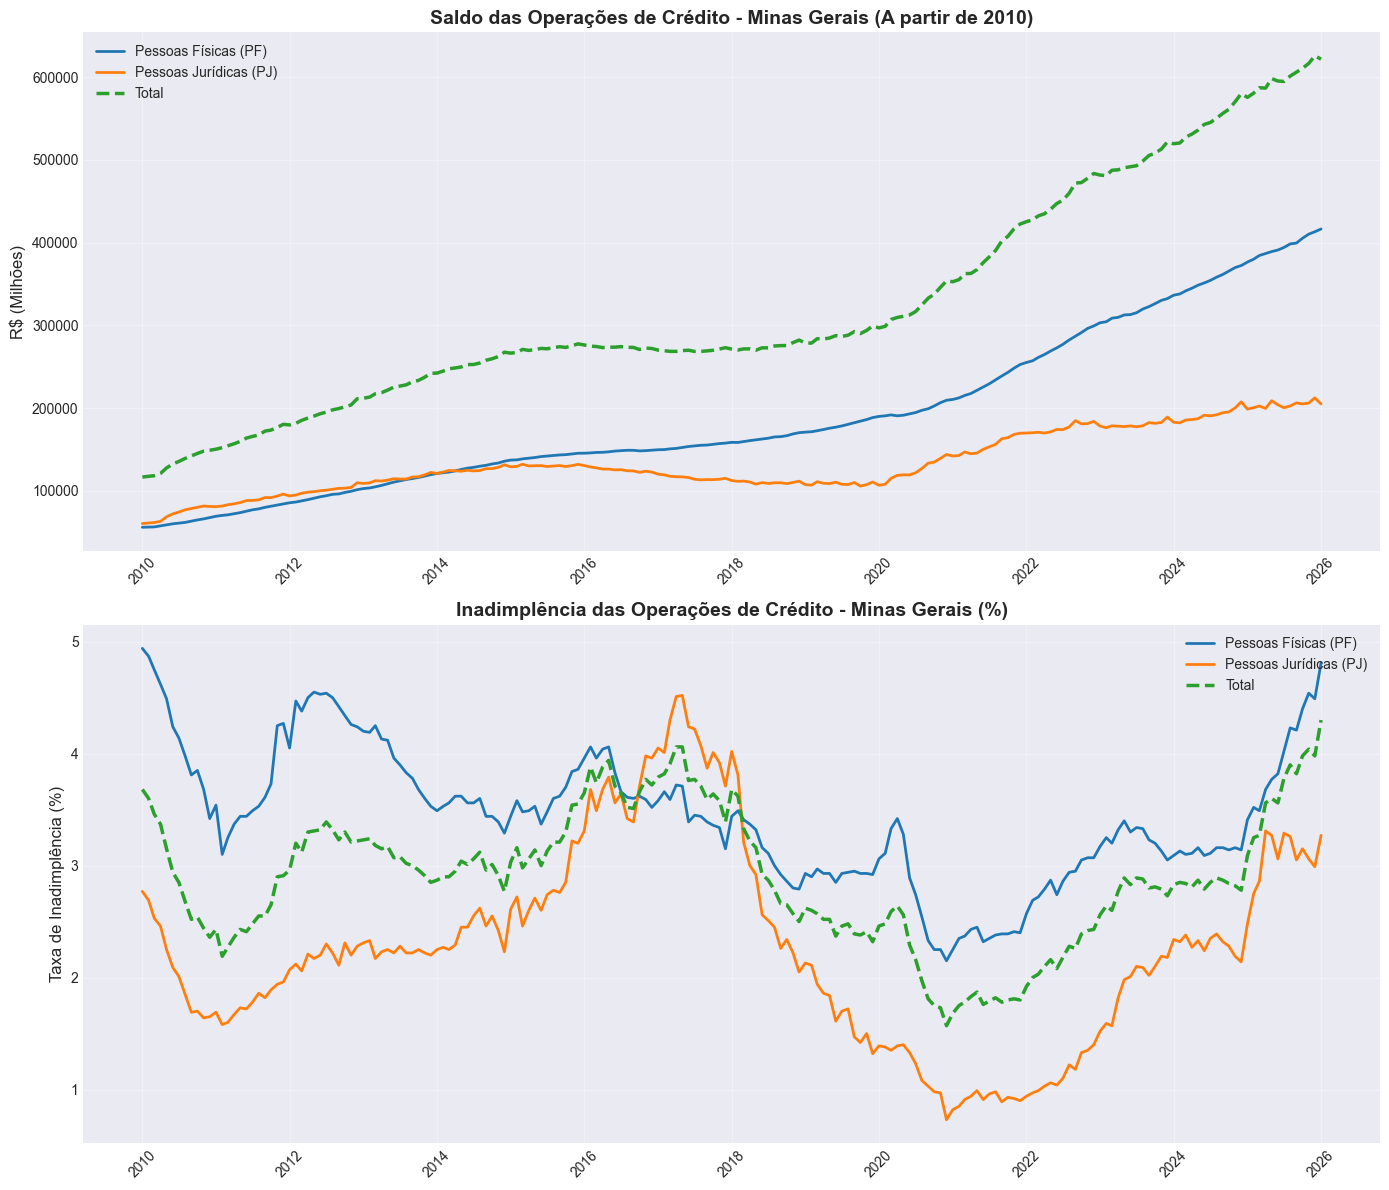

In [5]:
# Configurando o estilo visual para melhor apresentação
plt.style.use('seaborn-v0_8-darkgrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# Filtrando dados a partir de 2010 para melhor visualização
df_plot = df_mg.loc['2010-01-01':]

# ===== GRÁFICO 1: Saldo das Operações de Crédito =====
ax1.plot(df_plot.index, df_plot['Saldo_PF_R$Milhoes'], 
         label='Pessoas Físicas (PF)', color='tab:blue', linewidth=2)
ax1.plot(df_plot.index, df_plot['Saldo_PJ_R$Milhoes'], 
         label='Pessoas Jurídicas (PJ)', color='tab:orange', linewidth=2)
ax1.plot(df_plot.index, df_plot['Saldo_Total_R$Milhoes'], 
         label='Total', color='tab:green', linewidth=2.5, linestyle='--')
ax1.set_title('Saldo das Operações de Crédito - Minas Gerais (A partir de 2010)', 
              fontsize=14, fontweight='bold')
ax1.set_ylabel('R$ (Milhões)', fontsize=12)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# ===== GRÁFICO 2: Inadimplência das Operações de Crédito =====
ax2.plot(df_plot.index, df_plot['Inadimplencia_PF_%'], 
         label='Pessoas Físicas (PF)', color='tab:blue', linewidth=2)
ax2.plot(df_plot.index, df_plot['Inadimplencia_PJ_%'], 
         label='Pessoas Jurídicas (PJ)', color='tab:orange', linewidth=2)
ax2.plot(df_plot.index, df_plot['Inadimplencia_Total_%'], 
         label='Total', color='tab:green', linewidth=2.5, linestyle='--')
ax2.set_title('Inadimplência das Operações de Crédito - Minas Gerais (%)', 
              fontsize=14, fontweight='bold')
ax2.set_ylabel('Taxa de Inadimplência (%)', fontsize=12)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

# Ajusta o layout para melhor apresentação
plt.tight_layout()
plt.show()